### after running all the other QC steps, we'll run this one to remove individual gridpoints that have lots of exceedances -- this suggests a data issue rather than a real phenomenon. This identifies 'repeat offender' gridpoints that exist especially in complex terrain. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from ari_exceedance_map_functions import *

In [2]:
dataset="conus404"

start_years = {"mrms":2018,"stage4":2002,"prism":1981,"ccpa":2019,'conus404':1981}
#start_years = {"prism":2002}
first_year = start_years[dataset]
if dataset=="conus404":
    last_year = 2023
else:
    last_year = 2025  ### one year after the last year of data

years = np.arange(first_year,last_year)

workdir = "/glade/work/rschumac/precip_data/extremerain/"


### first get the cleaned, edited files for each year and combine them into one big file. Do this across all ARIs and durations. 
### Only run this part once!!

In [3]:
for ari in [10,100,1000]:
    #for duration in [24,48,72]:
    for duration in [6]:

        print(str(ari)+"-year, "+str(duration)+"-hour")       
        events = pd.DataFrame()
        
        ## read in data
        for year in years:
            print(year)
            if ((dataset=="prism") & (year < 2002)) | (dataset=="conus404"):
                data_dir = workdir+"/"+dataset+"/"+str(duration).zfill(2)+"h/"
            else:   
                data_dir = workdir+"/"+dataset+"/auto_qc/"+str(duration).zfill(2)+"h/"

            if dataset=="conus404":
                events_this = pd.read_csv(data_dir+"/"+str(year)+"/"+dataset+"_"+str(year)+"_all_points_"+str(ari)+"y"+str(duration).zfill(2)+"h.csv")
            else:
                events_this = pd.read_csv(data_dir+"/"+str(year)+"/"+dataset+"_"+str(year)+"_cleaned_"+str(ari)+"y"+str(duration).zfill(2)+"h_edit.csv")
            
            events = pd.concat([events,events_this])
        
        ## write back out a csv with these years combined
        events.to_csv(data_dir+"/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_"+str(ari)+"y"+str(duration).zfill(2)+"h_edit.csv", index=False)

        if (dataset=="conus404"):
            continue  ### no removed points for conus404
                        
        ### and repeat for the 'removed' files
        removed = pd.DataFrame()
        
        ## read in data
        for year in years:
            print(year)
            if (dataset=="prism") & (year < 2002):
                data_dir = workdir+"/"+dataset+"/"+str(duration).zfill(2)+"h/"
            else:   
                data_dir = workdir+"/"+dataset+"/auto_qc/"+str(duration).zfill(2)+"h/"
                
            removed_this = pd.read_csv(data_dir+"/"+str(year)+"/"+dataset+"_"+str(year)+"_removed_points_"+str(ari)+"y"+str(duration).zfill(2)+"h.csv")
            
            removed = pd.concat([removed,removed_this])
        
        ## write back out a csv with these years combined
        removed.to_csv(data_dir+"/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_"+str(ari)+"y"+str(duration).zfill(2)+"h.csv", index=False)

print("done!")


10-year, 6-hour
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
100-year, 6-hour
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
1000-year, 6-hour
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
done!


### now, focus in on a couple ARI/duration combos for the QC process. 
#### recommended choices here are 100,24 for the first pass, and then 100,48

In [51]:
ari=10   ### recommended choices here are 10,24 for the first pass, and then 100,24 for second, then 10,48 for third
duration=48
pass_number = 3  ### first pass should be 1, etc.
               
data_dir = workdir+"/"+dataset+"/auto_qc/"+str(duration)+"h/"

In [52]:
events = pd.read_csv(data_dir+"/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_"+str(ari)+"y"+str(duration)+"h_edit.csv")

In [53]:
events

,lat,lon,time,tp,tp_minus_ari,tp_pct_of_ari,event_num
0,24.500000,-81.791667,2020-09-13 12:00:00,278.233400,53.845319,1.239965,0
1,24.500000,-81.791667,2020-09-14 12:00:00,286.081180,61.693097,1.274939,0
2,24.541667,-81.791667,2005-08-27 12:00:00,240.714510,16.809049,1.075072,0
3,24.541667,-81.791667,2020-09-13 12:00:00,244.110600,20.205137,1.090240,0
4,24.541667,-81.791667,2020-09-14 12:00:00,254.098270,30.192808,1.134846,0
...,...,...,...,...,...,...,...
997055,49.125000,-94.958333,2002-06-11 12:00:00,102.833830,1.159255,1.011402,1
997056,49.125000,-94.833333,2019-09-21 12:00:00,103.615000,2.063870,1.020323,5
997057,49.125000,-94.833333,2019-09-22 12:00:00,107.190240,5.639111,1.055530,3
997058,49.166667,-94.833333,2019-09-21 12:00:00,103.170235,1.544835,1.015201,5


In [54]:
events.value_counts(subset=['lat','lon']).head(40)

lat        lon        
37.750000  -119.166667    31
37.375000  -114.666667    26
38.458333  -108.375000    26
38.750000  -107.166667    26
37.750000  -119.208333    26
38.500000  -108.416667    25
39.708333  -120.583333    25
37.791667  -119.166667    25
32.083333  -106.625000    25
39.708333  -120.541667    25
36.833333  -118.333333    24
38.416667  -112.333333    23
38.458333  -108.416667    23
38.416667  -108.333333    23
37.708333  -119.166667    23
35.541667  -82.125000     22
38.708333  -107.125000    22
39.291667  -119.833333    21
38.750000  -107.125000    21
36.916667  -118.333333    21
37.333333  -114.666667    21
37.791667  -119.208333    20
34.625000  -108.083333    20
35.500000  -82.166667     20
34.416667  -117.625000    20
37.500000  -118.750000    20
37.708333  -119.208333    19
38.708333  -107.083333    19
37.916667  -110.750000    19
38.500000  -108.375000    19
46.250000  -109.541667    19
34.791667  -119.500000    19
37.750000  -119.125000    19
46.333333  -109.2916

In [55]:
#### choose a cutoff for how many to allow.
#### settings for Stage IV:
####  for first pass, 10y24h: 15+ occurrences, restricted to west of -105W
#### for second pass, 100y24: 4+ occurrences, west of -105W
#### for third pass, 10y48h, 20+ occurrences, no spatial restriction

#### settings for PRISM (full 1981-2024 dataset):
####  for first pass, 10y24h: 25+ occurrences, restricted to west of -105W
#### for second pass, 100y24: 5+ occurrences, west of -105W
#### for third pass, 10y48h, 30+ occurrences, west of -105W

#### settings for MRMS (shorter record):
####  for first pass, 10y24h: 7+ occurrences, *no* spatial restriction 
#### for second pass, 100y24: 4+ occurrences
#### for third pass, 10y48h, 10+ occurrences

if pass_number==1:
    no_more_than = 15 #15  ### set a threshold for the most exceedances we'll allow at a single point
elif pass_number==2:
    no_more_than = 4 #4
else:
    no_more_than = 20 # 20

### find these rows based on https://stackoverflow.com/a/74693330
events_at_repeat_points = events.groupby(["lat", "lon"]).filter(lambda x: len(x) >= no_more_than) 

### also filter based on longitude to limit to only western points
#events_at_repeat_points = events_at_repeat_points[(events_at_repeat_points.lon < -105.)] # & (events_at_repeat_points.lon > -120.)]

events_at_repeat_points

,lat,lon,time,tp,tp_minus_ari,tp_pct_of_ari,event_num
126335,32.083333,-106.625000,2006-07-07 12:00:00,68.49970,4.642764,1.072706,0
126336,32.083333,-106.625000,2006-07-08 12:00:00,96.57218,32.715243,1.512321,0
126337,32.083333,-106.625000,2006-07-29 12:00:00,80.61885,16.761912,1.262492,0
126338,32.083333,-106.625000,2006-07-30 12:00:00,95.77899,31.922053,1.499900,0
126339,32.083333,-106.625000,2006-07-31 12:00:00,107.42665,43.569712,1.682302,0
...,...,...,...,...,...,...,...
542745,39.708333,-120.541667,2017-02-09 12:00:00,141.63107,5.223861,1.038296,0
542746,39.708333,-120.541667,2017-11-17 12:00:00,154.38884,17.981628,1.131823,0
542747,39.708333,-120.541667,2019-02-15 12:00:00,173.96951,37.562301,1.275369,1
542748,39.708333,-120.541667,2021-10-26 12:00:00,180.44226,44.035049,1.322821,0


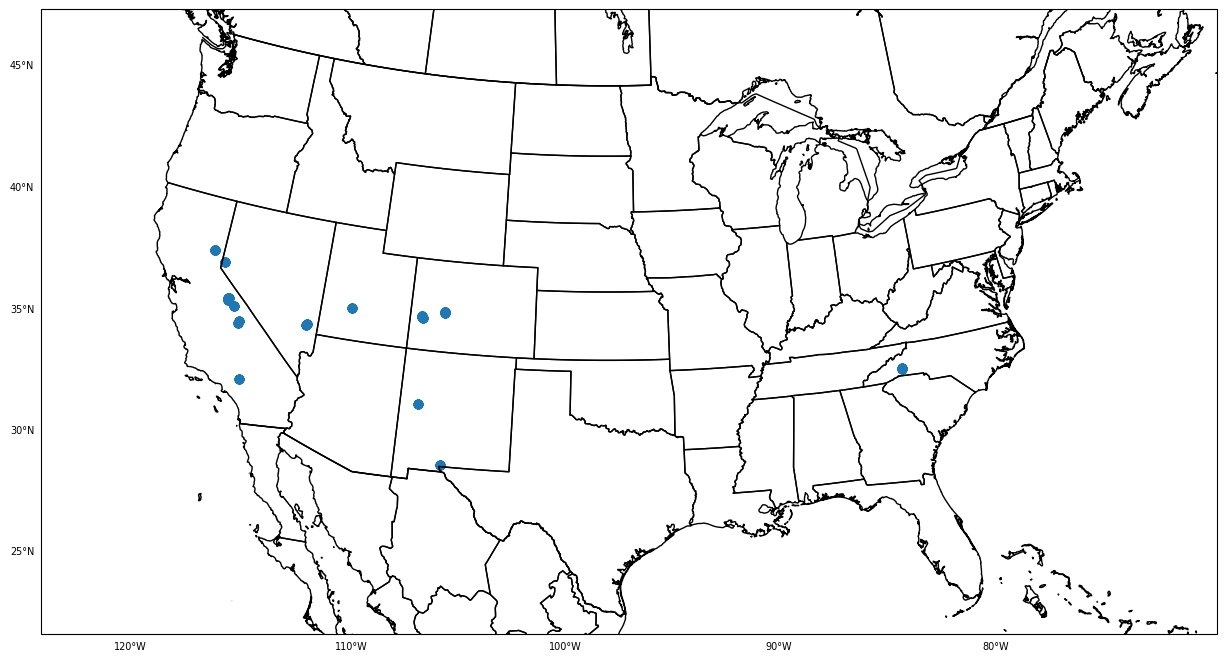

In [56]:
#### map of where these are

crs = ccrs.LambertConformal(central_longitude=-98., central_latitude=40.)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 6.5), 
                          constrained_layout=True,
                      subplot_kw={'projection': crs})

#axlist = axarr.flatten()
#for ax in axlist:
#plot_background(ax,-124,-103,29.5,49.5)
plot_background(ax,-124,-70,22,49.5)

ax.scatter(events_at_repeat_points.lon, events_at_repeat_points.lat, 
            transform=ccrs.PlateCarree())

plt.show()

In [57]:
df1000_72h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_1000y72h_edit.csv")
df100_72h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_100y72h_edit.csv")
df10_72h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_10y72h_edit.csv")

df1000_48h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_1000y48h_edit.csv")
df100_48h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_100y48h_edit.csv")
df10_48h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_10y48h_edit.csv")

df1000_24h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_1000y24h_edit.csv")
df100_24h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_100y24h_edit.csv")
df10_24h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_10y24h_edit.csv")

removed_1000_72h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_1000y72h.csv")
removed_100_72h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_100y72h.csv")
removed_10_72h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_10y72h.csv")

removed_1000_48h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_1000y48h.csv")
removed_100_48h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_100y48h.csv")
removed_10_48h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_10y48h.csv")

removed_1000_24h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_1000y24h.csv")
removed_100_24h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_100y24h.csv")
removed_10_24h = pd.read_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_10y24h.csv")


### now find any points that are extremely close to these and remove them too

In [58]:
## lat/lon buffer around the centerpoint
#if dataset=="prism":
#    latlon_buf = 0.10 ### a bit bigger for PRISM
#else:
latlon_buf = 0.05

rows_to_drop_1000_72h = pd.DataFrame()
rows_to_drop_100_72h = pd.DataFrame()
rows_to_drop_10_72h = pd.DataFrame()
rows_to_drop_1000_48h = pd.DataFrame()
rows_to_drop_100_48h = pd.DataFrame()
rows_to_drop_10_48h = pd.DataFrame()
rows_to_drop_1000_24h = pd.DataFrame()
rows_to_drop_100_24h = pd.DataFrame()
rows_to_drop_10_24h = pd.DataFrame()

for i in range(0,len(events_at_repeat_points)):
    this_lon = events_at_repeat_points.iloc[i].lon
    this_lat = events_at_repeat_points.iloc[i].lat
    this_time = events_at_repeat_points.iloc[i].time
    
    more_rows_to_drop_1000_72h = df1000_72h[(df1000_72h.time==this_time) & (df1000_72h.lon >= this_lon-latlon_buf) & (df1000_72h.lon <= this_lon+latlon_buf) & (df1000_72h.lat >= this_lat-latlon_buf) & (df1000_72h.lat <= this_lat+latlon_buf)] 
    rows_to_drop_1000_72h = pd.concat([rows_to_drop_1000_72h,more_rows_to_drop_1000_72h])

    ### now also find the rows in the same area in the 100 & 10-year files
    more_rows_to_drop_100_72h = df100_72h[(df100_72h.time==this_time) & (df100_72h.lon >= this_lon-latlon_buf) & (df100_72h.lon <= this_lon+latlon_buf) & (df100_72h.lat >= this_lat-latlon_buf) & (df100_72h.lat <= this_lat+latlon_buf)] 
    more_rows_to_drop_10_72h = df10_72h[(df10_72h.time==this_time) & (df10_72h.lon >= this_lon-latlon_buf) & (df10_72h.lon <= this_lon+latlon_buf) & (df10_72h.lat >= this_lat-latlon_buf) & (df10_72h.lat <= this_lat+latlon_buf)] 

    rows_to_drop_100_72h = pd.concat([rows_to_drop_100_72h,more_rows_to_drop_100_72h])
    rows_to_drop_10_72h = pd.concat([rows_to_drop_10_72h,more_rows_to_drop_10_72h])  

    #### repeat for 48h
    more_rows_to_drop_1000_48h = df1000_48h[(df1000_48h.time==this_time) & (df1000_48h.lon >= this_lon-latlon_buf) & (df1000_48h.lon <= this_lon+latlon_buf) & (df1000_48h.lat >= this_lat-latlon_buf) & (df1000_48h.lat <= this_lat+latlon_buf)] 
    rows_to_drop_1000_48h = pd.concat([rows_to_drop_1000_48h,more_rows_to_drop_1000_48h])

    ### now also find the rows in the same area in the 100 & 10-year files
    more_rows_to_drop_100_48h = df100_48h[(df100_48h.time==this_time) & (df100_48h.lon >= this_lon-latlon_buf) & (df100_48h.lon <= this_lon+latlon_buf) & (df100_48h.lat >= this_lat-latlon_buf) & (df100_48h.lat <= this_lat+latlon_buf)] 
    more_rows_to_drop_10_48h = df10_48h[(df10_48h.time==this_time) & (df10_48h.lon >= this_lon-latlon_buf) & (df10_48h.lon <= this_lon+latlon_buf) & (df10_48h.lat >= this_lat-latlon_buf) & (df10_48h.lat <= this_lat+latlon_buf)] 

    rows_to_drop_100_48h = pd.concat([rows_to_drop_100_48h,more_rows_to_drop_100_48h])
    rows_to_drop_10_48h = pd.concat([rows_to_drop_10_48h,more_rows_to_drop_10_48h]) 

    ### and 24
    more_rows_to_drop_1000_24h = df1000_24h[(df1000_24h.time==this_time) & (df1000_24h.lon >= this_lon-latlon_buf) & (df1000_24h.lon <= this_lon+latlon_buf) & (df1000_24h.lat >= this_lat-latlon_buf) & (df1000_24h.lat <= this_lat+latlon_buf)] 
    rows_to_drop_1000_24h = pd.concat([rows_to_drop_1000_24h,more_rows_to_drop_1000_24h])

    ### now also find the rows in the same area in the 100 & 10-year files
    more_rows_to_drop_100_24h = df100_24h[(df100_24h.time==this_time) & (df100_24h.lon >= this_lon-latlon_buf) & (df100_24h.lon <= this_lon+latlon_buf) & (df100_24h.lat >= this_lat-latlon_buf) & (df100_24h.lat <= this_lat+latlon_buf)] 
    more_rows_to_drop_10_24h = df10_24h[(df10_24h.time==this_time) & (df10_24h.lon >= this_lon-latlon_buf) & (df10_24h.lon <= this_lon+latlon_buf) & (df10_24h.lat >= this_lat-latlon_buf) & (df10_24h.lat <= this_lat+latlon_buf)] 

    rows_to_drop_100_24h = pd.concat([rows_to_drop_100_24h,more_rows_to_drop_100_24h])
    rows_to_drop_10_24h = pd.concat([rows_to_drop_10_24h,more_rows_to_drop_10_24h]) 

rows_to_drop_1000_72h = rows_to_drop_1000_72h.drop_duplicates()
rows_to_drop_100_72h.drop_duplicates(inplace=True)
rows_to_drop_10_72h.drop_duplicates(inplace=True)

rows_to_drop_1000_48h = rows_to_drop_1000_48h.drop_duplicates()
rows_to_drop_100_48h.drop_duplicates(inplace=True)
rows_to_drop_10_48h.drop_duplicates(inplace=True)

rows_to_drop_1000_24h = rows_to_drop_1000_24h.drop_duplicates()
rows_to_drop_100_24h.drop_duplicates(inplace=True)
rows_to_drop_10_24h.drop_duplicates(inplace=True)


rows_to_drop_100_48h


,time,lat,lon,tp,tp_minus_ari,tp_pct_of_ari,event_num
5900,2006-08-16 12:00:00,32.083333,-106.625000,103.100000,0.276325,1.002687,1
11571,2008-07-27 12:00:00,32.083333,-106.625000,115.385666,12.561993,1.122170,0
11598,2008-07-28 12:00:00,32.083333,-106.625000,130.882130,28.058453,1.272879,0
1405,2003-02-13 12:00:00,34.416667,-117.625000,181.171840,15.583470,1.094110,0
1406,2003-02-13 12:00:00,34.416667,-117.583333,170.906850,11.007468,1.068840,0
...,...,...,...,...,...,...,...
55490,2023-01-01 12:00:00,39.333333,-119.833333,156.952670,5.269439,1.034740,0
5215,2006-01-01 12:00:00,39.708333,-120.583333,337.883500,103.365192,1.440755,0
5216,2006-01-01 12:00:00,39.708333,-120.541667,314.187260,91.792146,1.412744,0
5211,2006-01-01 12:00:00,39.666667,-120.500000,328.214970,39.516191,1.136877,0


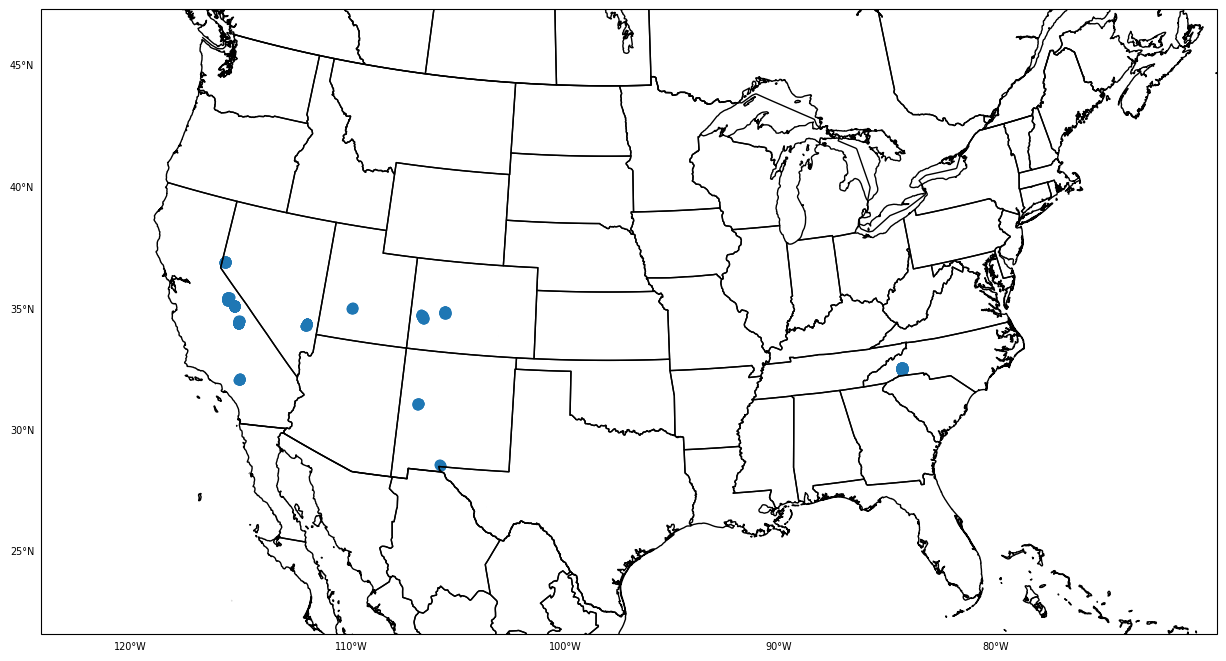

In [59]:
#### map of where these are

crs = ccrs.LambertConformal(central_longitude=-98., central_latitude=40.)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 6.5), 
                          constrained_layout=True,
                      subplot_kw={'projection': crs})

#axlist = axarr.flatten()
#for ax in axlist:
plot_background(ax,-124,-70,22,49.5)
#plot_background(ax,-124,-104,29.5,49.5)

ax.scatter(rows_to_drop_10_24h.lon, rows_to_drop_10_24h.lat, 
            transform=ccrs.PlateCarree())

plt.show()

#### now drop those rows from the original dataframe. Method from here: https://www.includehelp.com/python/how-to-remove-rows-in-a-pandas-dataframe-if-the-same-row-exists-in-another-dataframe.aspx#:~:text=df1%20and%20df2.-,Remove%20rows%20in%20a%20Pandas%20dataframe%20if%20the%20same%20row,then%20drop%20the%20common%20rows.

In [60]:
df1000_72h_edit = pd.merge(df1000_72h,rows_to_drop_1000_72h, indicator=True, how='outer').query('_merge=="left_only"').drop('_merge', axis=1)
df100_72h_edit = pd.merge(df100_72h,rows_to_drop_100_72h, indicator=True, how='outer').query('_merge=="left_only"').drop('_merge', axis=1)
df10_72h_edit = pd.merge(df10_72h,rows_to_drop_10_72h, indicator=True, how='outer').query('_merge=="left_only"').drop('_merge', axis=1)

print("df1000_72h length went from "+str(len(df1000_72h))+" to "+str(len(df1000_72h_edit)))
print("df100_72h length went from "+str(len(df100_72h))+" to "+str(len(df100_72h_edit)))
print("df10_72h length went from "+str(len(df10_72h))+" to "+str(len(df10_72h_edit)))

#### 48h
df1000_48h_edit = pd.merge(df1000_48h,rows_to_drop_1000_48h, indicator=True, how='outer').query('_merge=="left_only"').drop('_merge', axis=1)
df100_48h_edit = pd.merge(df100_48h,rows_to_drop_100_48h, indicator=True, how='outer').query('_merge=="left_only"').drop('_merge', axis=1)
df10_48h_edit = pd.merge(df10_48h,rows_to_drop_10_48h, indicator=True, how='outer').query('_merge=="left_only"').drop('_merge', axis=1)

print("df1000_48h length went from "+str(len(df1000_48h))+" to "+str(len(df1000_48h_edit)))
print("df100_48h length went from "+str(len(df100_48h))+" to "+str(len(df100_48h_edit)))
print("df10_48h length went from "+str(len(df10_48h))+" to "+str(len(df10_48h_edit)))

### 24h
df1000_24h_edit = pd.merge(df1000_24h,rows_to_drop_1000_24h, indicator=True, how='outer').query('_merge=="left_only"').drop('_merge', axis=1)
df100_24h_edit = pd.merge(df100_24h,rows_to_drop_100_24h, indicator=True, how='outer').query('_merge=="left_only"').drop('_merge', axis=1)
df10_24h_edit = pd.merge(df10_24h,rows_to_drop_10_24h, indicator=True, how='outer').query('_merge=="left_only"').drop('_merge', axis=1)

print("df1000_24h length went from "+str(len(df1000_24h))+" to "+str(len(df1000_24h_edit)))
print("df100_24h length went from "+str(len(df100_24h))+" to "+str(len(df100_24h_edit)))
print("df10_24h length went from "+str(len(df10_24h))+" to "+str(len(df10_24h_edit)))

df1000_72h length went from 8137 to 8096
df100_72h length went from 102510 to 102299
df10_72h length went from 1546956 to 1545154
df1000_48h length went from 3857 to 3830
df100_48h length went from 62881 to 62725
df10_48h length went from 997060 to 995107
df1000_24h length went from 1357 to 1350
df100_24h length went from 30036 to 29969
df10_24h length went from 476483 to 475835


### OK, and now let's write these back out (both the edited dataframe and also the list of rows that were dropped to the "removed" files)


In [61]:
df1000_72h_edit.to_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_1000y72h_edit.csv", index=False)
df100_72h_edit.to_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_100y72h_edit.csv", index=False)
df10_72h_edit.to_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_10y72h_edit.csv", index=False)

df1000_48h_edit.to_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_1000y48h_edit.csv", index=False)
df100_48h_edit.to_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_100y48h_edit.csv", index=False)
df10_48h_edit.to_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_10y48h_edit.csv", index=False)

df1000_24h_edit.to_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_1000y24h_edit.csv", index=False)
df100_24h_edit.to_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_100y24h_edit.csv", index=False)
df10_24h_edit.to_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_events_10y24h_edit.csv", index=False)



In [69]:
removed_1000_72h = pd.concat([removed_1000_72h,rows_to_drop_1000_72h]).drop_duplicates()
removed_100_72h = pd.concat([removed_100_72h,rows_to_drop_100_72h]).drop_duplicates()
removed_10_72h = pd.concat([removed_10_72h,rows_to_drop_10_72h]).drop_duplicates()

removed_1000_48h = pd.concat([removed_1000_48h,rows_to_drop_1000_48h]).drop_duplicates()
removed_100_48h = pd.concat([removed_100_48h,rows_to_drop_100_48h]).drop_duplicates()
removed_10_48h = pd.concat([removed_10_48h,rows_to_drop_10_48h]).drop_duplicates()

removed_1000_24h = pd.concat([removed_1000_24h,rows_to_drop_1000_24h]).drop_duplicates()
removed_100_24h = pd.concat([removed_100_24h,rows_to_drop_100_24h]).drop_duplicates()
removed_10_24h = pd.concat([removed_10_24h,rows_to_drop_10_24h]).drop_duplicates()

removed_1000_72h.to_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_1000y72h.csv", index=False)
removed_100_72h.to_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_100y72h.csv", index=False)
removed_10_72h.to_csv(workdir+"/"+dataset+"/auto_qc/72h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_10y72h.csv", index=False)

removed_1000_48h.to_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_1000y48h.csv", index=False)
removed_100_48h.to_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_100y48h.csv", index=False)
removed_10_48h.to_csv(workdir+"/"+dataset+"/auto_qc/48h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_10y48h.csv", index=False)

removed_1000_24h.to_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_1000y24h.csv", index=False)
removed_100_24h.to_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_100y24h.csv", index=False)
removed_10_24h.to_csv(workdir+"/"+dataset+"/auto_qc/24h/"+dataset+"_"+str(years[0])+'-'+str(years[-1])+"_removed_points_10y24h.csv", index=False)


In [68]:
df100_48h_edit[df100_48h_edit.time=='2015-10-05 12:00:00']

,time,lat,lon,tp,tp_minus_ari,tp_pct_of_ari,event_num
31546,2015-10-05 12:00:00,32.791667,-79.750000,319.28210,17.313369,1.057335,1
31547,2015-10-05 12:00:00,32.791667,-79.708333,319.37880,16.365731,1.054010,1
31548,2015-10-05 12:00:00,32.833333,-79.791667,327.16547,29.455423,1.098940,1
31549,2015-10-05 12:00:00,32.833333,-79.750000,339.95917,39.779194,1.132518,1
31550,2015-10-05 12:00:00,32.833333,-79.708333,342.82434,39.364429,1.129719,1
...,...,...,...,...,...,...,...
32565,2015-10-05 12:00:00,34.250000,-80.916667,260.55322,22.945540,1.096569,1
32566,2015-10-05 12:00:00,34.250000,-80.875000,260.87390,22.759892,1.095584,1
32567,2015-10-05 12:00:00,34.250000,-80.833333,260.47052,21.674978,1.090768,1
32568,2015-10-05 12:00:00,34.250000,-80.791667,259.47263,19.927595,1.083189,1


In [67]:
rows_to_drop_100_48h[rows_to_drop_100_48h.time=='2015-10-05 12:00:00']

,time,lat,lon,tp,tp_minus_ari,tp_pct_of_ari,event_num
